In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pylab as  pl

In [4]:
df = pd.read_csv("FuelConsumption.csv")
cdf = df[["ENGINESIZE", "CYLINDERS", "FUELCONSUMPTION_CITY", "FUELCONSUMPTION_HWY", "FUELCONSUMPTION_COMB", "CO2EMISSIONS"]]
cdf

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,9.9,6.7,8.5,196
1,2.4,4,11.2,7.7,9.6,221
2,1.5,4,6.0,5.8,5.9,136
3,3.5,6,12.7,9.1,11.1,255
4,3.5,6,12.1,8.7,10.6,244
...,...,...,...,...,...,...
1062,3.0,6,13.4,9.8,11.8,271
1063,3.2,6,13.2,9.5,11.5,264
1064,3.0,6,13.4,9.8,11.8,271
1065,3.2,6,12.9,9.3,11.3,260


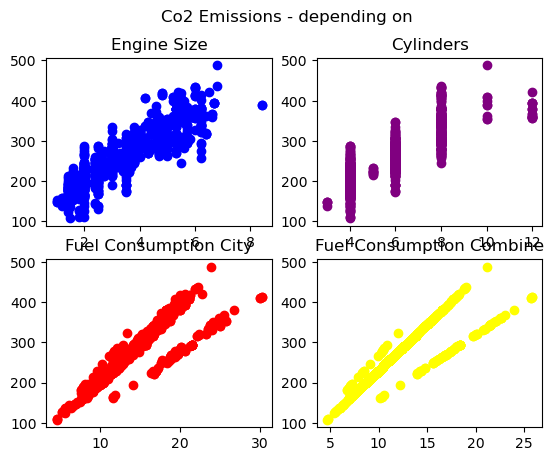

In [30]:
fig, ax = plt.subplots(2, 2)
fig.suptitle("Co2 Emissions - depending on")
ax[0][0].scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS, color = "blue")
ax[0][0].set_title("Engine Size")
ax[0][1].scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS, color = "purple")
ax[0][1].set_title("Cylinders")
ax[1][0].scatter(cdf.FUELCONSUMPTION_CITY, cdf.CO2EMISSIONS, color = "red")
ax[1][0].set_title("Fuel Consumption City")
ax[1][1].scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS, color = "yellow")
ax[1][1].set_title("Fuel Consumption Combine")
plt.show()

In [5]:
msk = np.random.rand(len(cdf)) < 0.8
train = cdf[msk]
test = cdf[~msk]

In [6]:
from sklearn import linear_model
regr = linear_model.LinearRegression()
train_x = np.asanyarray(train[["ENGINESIZE", "CYLINDERS", "FUELCONSUMPTION_CITY", "FUELCONSUMPTION_COMB"]])
train_y = np.asanyarray(train[["CO2EMISSIONS"]]) 
regr.fit(train_x, train_y)
print(regr.coef_)
print(regr.intercept_)

[[11.67476409  7.38173589  1.42824125  7.62305971]]
[66.38499392]


In [7]:
test_x = np.asanyarray(test[["ENGINESIZE", "CYLINDERS", "FUELCONSUMPTION_CITY", "FUELCONSUMPTION_COMB"]])
test_y = np.asanyarray(test[["CO2EMISSIONS"]]) 
regr.score(test_x, test_y)

0.8594836878979408